## Dataset Structure

The division of data within the Crack Segmentation Dataset is outlined as follows:

- **Training set**: Consists of 3717 images with corresponding annotations.

- **Testing set**: Comprises 112 images along with their respective annotations.

- **Validation set**: Includes 200 images with their corresponding annotations.

In [ ]:
# !uv pip install ultralytics
import ultralytics
ultralytics.checks()

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo26n-seg.pt")  # load a pretrained model (recommended for training)

In [ ]:
# Train the model
results = model.train(
    data=r"D:\HP\OneDrive\Desktop\学校\课程\专业课\大数据综合工程设计\crack-seg\dataset\crack-seg\data.yaml",
    epochs=3,
    imgsz=640,
    batch=64,
    workers=0,
)


image 1/1 D:\HP\Downloads\R.jpg: 640x480 2 cracks, 23.5ms
Speed: 1.8ms preprocess, 23.5ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 480)


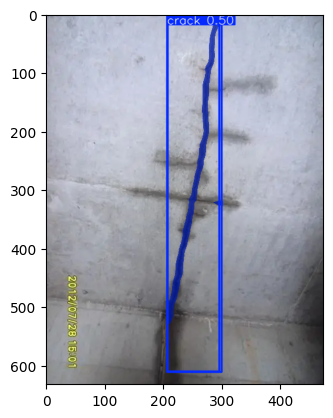

In [18]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load a model
modelp = YOLO("runs/segment/train-2/weights/best.pt")  # load a fine-tuned model

# Inference using the model (img/video/stream)
prediction_results = modelp.predict(
    r"D:\HP\Downloads\R.jpg",
    save=False,
    conf=0.1,
)

plt.imshow(prediction_results[0].plot()[..., ::-1])  # 转换 BGR 到 RGB

# 提取几何特征

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.morphology import skeletonize
import pandas as pd

bbox 坐标: (206, 0, 299, 611)
截取图像尺寸: (611, 93, 3)


True

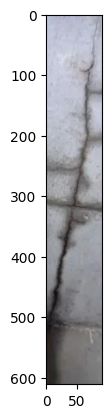

In [20]:
# 获取第一个预测结果
result = prediction_results[0]

# 获取原图（numpy 数组，BGR 格式）
img = result.orig_img

# 获取所有 bbox（xyxy 格式：x1, y1, x2, y2）
boxes = result.boxes.xyxy.cpu().numpy().astype(int)

# 截取第一个 bbox 对应的图像区域
x1, y1, x2, y2 = boxes[0]
bbox_img = img[y1:y2, x1:x2]

print(f"bbox 坐标: ({x1}, {y1}, {x2}, {y2})")
print(f"截取图像尺寸: {bbox_img.shape}")
plt.imshow(bbox_img[:, :, ::-1])  # 转换 BGR 到 RGB

cv2.imwrite("bbox_img.png", bbox_img)

In [21]:
# ========== 获取 mask ==========
masks = result.masks.data.cpu().numpy()  # (N, H, W) 二值 mask
mask = masks[0]  # 取第一个检测目标的 mask

# 1. mask 面积
mask_area = int(mask.sum())

# 2. 面积比（mask面积 / bbox面积）
bbox_w, bbox_h = x2 - x1, y2 - y1
bbox_area = bbox_w * bbox_h
rectangularity = mask_area / bbox_area if bbox_area > 0 else 0

# 3. 细长度（最小外接矩形的长宽比）
mask_uint8 = (mask * 255).astype(np.uint8)
contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest_contour)
    rw, rh = rect[1]
    slenderness = max(rw, rh) / min(rw, rh) if min(rw, rh) > 0 else 0
else:
    slenderness = 0
    rect = None

# 4. 主方向（最小外接矩形的角度）
if rect is not None:
    major_direction = rect[2]
    if rect[1][0] < rect[1][1]:
        major_direction = 90 + major_direction
else:
    major_direction = 0

# 5. 边界复杂度（周长² / 面积）
if contours:
    perimeter = cv2.arcLength(largest_contour, True)
    boundary_complexity = (perimeter ** 2) / mask_area if mask_area > 0 else 0
else:
    boundary_complexity = 0

# 6. 骨架长度 & 7. 分支数量
skel = skeletonize(mask > 0).astype(np.uint8)
skeleton_length = int(skel.sum())

branch_points = 0
end_points = 0
h, w = skel.shape
for i in range(1, h - 1):
    for j in range(1, w - 1):
        if skel[i, j] == 1:
            neighbors = skel[i-1:i+2, j-1:j+2].sum() - 1
            if neighbors >= 3:
                branch_points += 1
            elif neighbors == 1:
                end_points += 1

# 8. 区域颜色统计
# mask 尺寸可能与原图不一致，需缩放到原图大小
if mask.shape != img.shape[:2]:
    mask_full = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
else:
    mask_full = mask
mask_bool = mask_full.astype(bool)
pixel_values = img[mask_bool]  # (N, 3) BGR
color_mean = pixel_values.mean(axis=0)
color_std = pixel_values.std(axis=0)

# ========== 输出结果 ==========
features = {
    "mask面积": mask_area,
    "面积比": round(rectangularity, 4),
    "细长度": round(slenderness, 4),
    "主方向(°)": round(major_direction, 2),
    "边界复杂度": round(boundary_complexity, 4),
    "骨架长度": skeleton_length,
    "分支数量": branch_points,
    "BGR均值": [round(v, 2) for v in color_mean],
    "BGR标准差": [round(v, 2) for v in color_std],
}

df = pd.DataFrame([features])
df

,mask面积,面积比,细长度,主方向(°),边界复杂度,骨架长度,分支数量,BGR均值,BGR标准差
0,5758,0.1013,22.547,-80.87,233.0142,549,0,"[105.42, 102.06, 104.19]","[50.08, 46.78, 44.94]"
